# PTF–EPEX Price Comparison — Turkey vs Germany

> Comparing Turkish day-ahead electricity prices (PTF) with German EPEX spot prices,
> converting PTF from TRY/MWh to EUR/MWh for a like-for-like analysis.

**Data sources:**
- EPİAŞ Transparency Platform — hourly PTF (Turkish day-ahead price)
- SMARD API (Bundesnetzagentur) — hourly German EPEX day-ahead price

**Period:** 2023–2025 (26,280 hourly records)

---

## 1 — Install & Import

In [4]:
!pip install eptr2 -q
print('eptr2 installed.')

eptr2 installed.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
from eptr2 import EPTR2
from google.colab import userdata
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 2 — Fetch PTF Data (EPİAŞ)

In [6]:
# ── Connect to EPİAŞ API ─────────────────────────────────────
username = userdata.get('EPIAS_USERNAME')
password = userdata.get('EPIAS_PASSWORD')
eptr     = EPTR2(username=username, password=password)

# ── Fetch PTF in yearly chunks (API limit: 1 year max) ───────
print('Fetching PTF data from EPİAŞ...')

chunks = [
    ('2023-01-01', '2023-12-31'),
    ('2024-01-01', '2024-12-31'),
    ('2025-01-01', '2025-12-31'),
]

dfs = []
for start, end in chunks:
    print(f'  Fetching {start} → {end}...')
    result = eptr.call('mcp', start_date=start, end_date=end)
    dfs.append(pd.DataFrame(result))

df_tr = pd.concat(dfs, ignore_index=True)
df_tr['date']    = pd.to_datetime(df_tr['date'])
df_tr            = df_tr.sort_values('date').reset_index(drop=True)
df_tr            = df_tr.rename(columns={'price': 'ptf_try'})
df_tr['ptf_eur'] = df_tr['priceEur'].astype(float)
df_tr['hour']    = df_tr['date'].dt.hour
df_tr['month']   = df_tr['date'].dt.month
df_tr['year']    = df_tr['date'].dt.year

print(f'\nPTF data     : {len(df_tr):,} hourly records')
print(f'Period       : {df_tr["date"].min().date()} → {df_tr["date"].max().date()}')
print(f'Avg PTF      : {df_tr["ptf_try"].mean():.1f} TRY/MWh')
print(f'Avg PTF (EUR): {df_tr["ptf_eur"].mean():.1f} €/MWh')

Dotenv file not found at .env.
Fetching PTF data from EPİAŞ...
  Fetching 2023-01-01 → 2023-12-31...
  Fetching 2024-01-01 → 2024-12-31...
  Fetching 2025-01-01 → 2025-12-31...

PTF data     : 26,304 hourly records
Period       : 2023-01-01 → 2025-12-31
Avg PTF      : 2348.1 TRY/MWh
Avg PTF (EUR): 70.4 €/MWh


## 3 — Fetch EPEX Data (SMARD)

In [7]:
# ── Fetch all hourly blocks from SMARD API ───────────────────
print('Fetching DE prices from SMARD...')

INDEX_URL  = 'https://www.smard.de/app/chart_data/4169/DE/index_hour.json'
timestamps = requests.get(INDEX_URL).json()['timestamps']
blocks     = sorted(timestamps)

records = []
for i, ts in enumerate(blocks):
    url  = f'https://www.smard.de/app/chart_data/4169/DE/4169_DE_hour_{ts}.json'
    data = requests.get(url).json().get('series', [])
    for entry in data:
        if entry[1] is not None:
            records.append({
                'timestamp': pd.to_datetime(entry[0], unit='ms', utc=True),
                'epex_eur':  entry[1]
            })
    if i % 40 == 0:
        print(f'  {i+1}/{len(blocks)} blocks fetched...')

df_de = (pd.DataFrame(records)
           .drop_duplicates('timestamp')
           .sort_values('timestamp'))
df_de['timestamp'] = df_de['timestamp'].dt.tz_localize(None)
df_de = df_de[df_de['epex_eur'] > -500]
df_de = df_de[
    (df_de['timestamp'] >= '2023-01-01') &
    (df_de['timestamp'] <= '2025-12-31')
].reset_index(drop=True)

print(f'\nDE data  : {len(df_de):,} hourly records')
print(f'Avg EPEX : {df_de["epex_eur"].mean():.1f} €/MWh')

Fetching DE prices from SMARD...
  1/397 blocks fetched...
  41/397 blocks fetched...
  81/397 blocks fetched...
  121/397 blocks fetched...
  161/397 blocks fetched...
  201/397 blocks fetched...
  241/397 blocks fetched...
  281/397 blocks fetched...
  321/397 blocks fetched...
  361/397 blocks fetched...

DE data  : 26,280 hourly records
Avg EPEX : 87.7 €/MWh


## 4 — Merge & Feature Engineering

In [8]:
# ── Align timestamps and merge ───────────────────────────────
df_tr['timestamp'] = df_tr['date'].dt.tz_localize(None)

df = pd.merge(
    df_tr[['timestamp', 'ptf_try', 'ptf_eur', 'hour', 'month', 'year']],
    df_de[['timestamp', 'epex_eur']],
    on='timestamp', how='inner'
)

df['spread_eur']      = df['ptf_eur'] - df['epex_eur']
df['ptf_premium_pct'] = (
    (df['ptf_eur'] - df['epex_eur']) /
    df['epex_eur'].abs() * 100
).round(1)

print(f'Merged dataset : {len(df):,} records')
print(f'Period         : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'\nAvg PTF (EUR)  : {df["ptf_eur"].mean():.1f} €/MWh')
print(f'Avg EPEX (EUR) : {df["epex_eur"].mean():.1f} €/MWh')
print(f'Avg spread     : {df["spread_eur"].mean():.1f} €/MWh')
print(f'PTF > EPEX     : {(df["ptf_eur"] > df["epex_eur"]).mean()*100:.1f}% of hours')

Merged dataset : 26,280 records
Period         : 2023-01-01 → 2025-12-31

Avg PTF (EUR)  : 70.4 €/MWh
Avg EPEX (EUR) : 87.7 €/MWh
Avg spread     : -17.3 €/MWh
PTF > EPEX     : 30.6% of hours


## 5 — Visualisation Panel

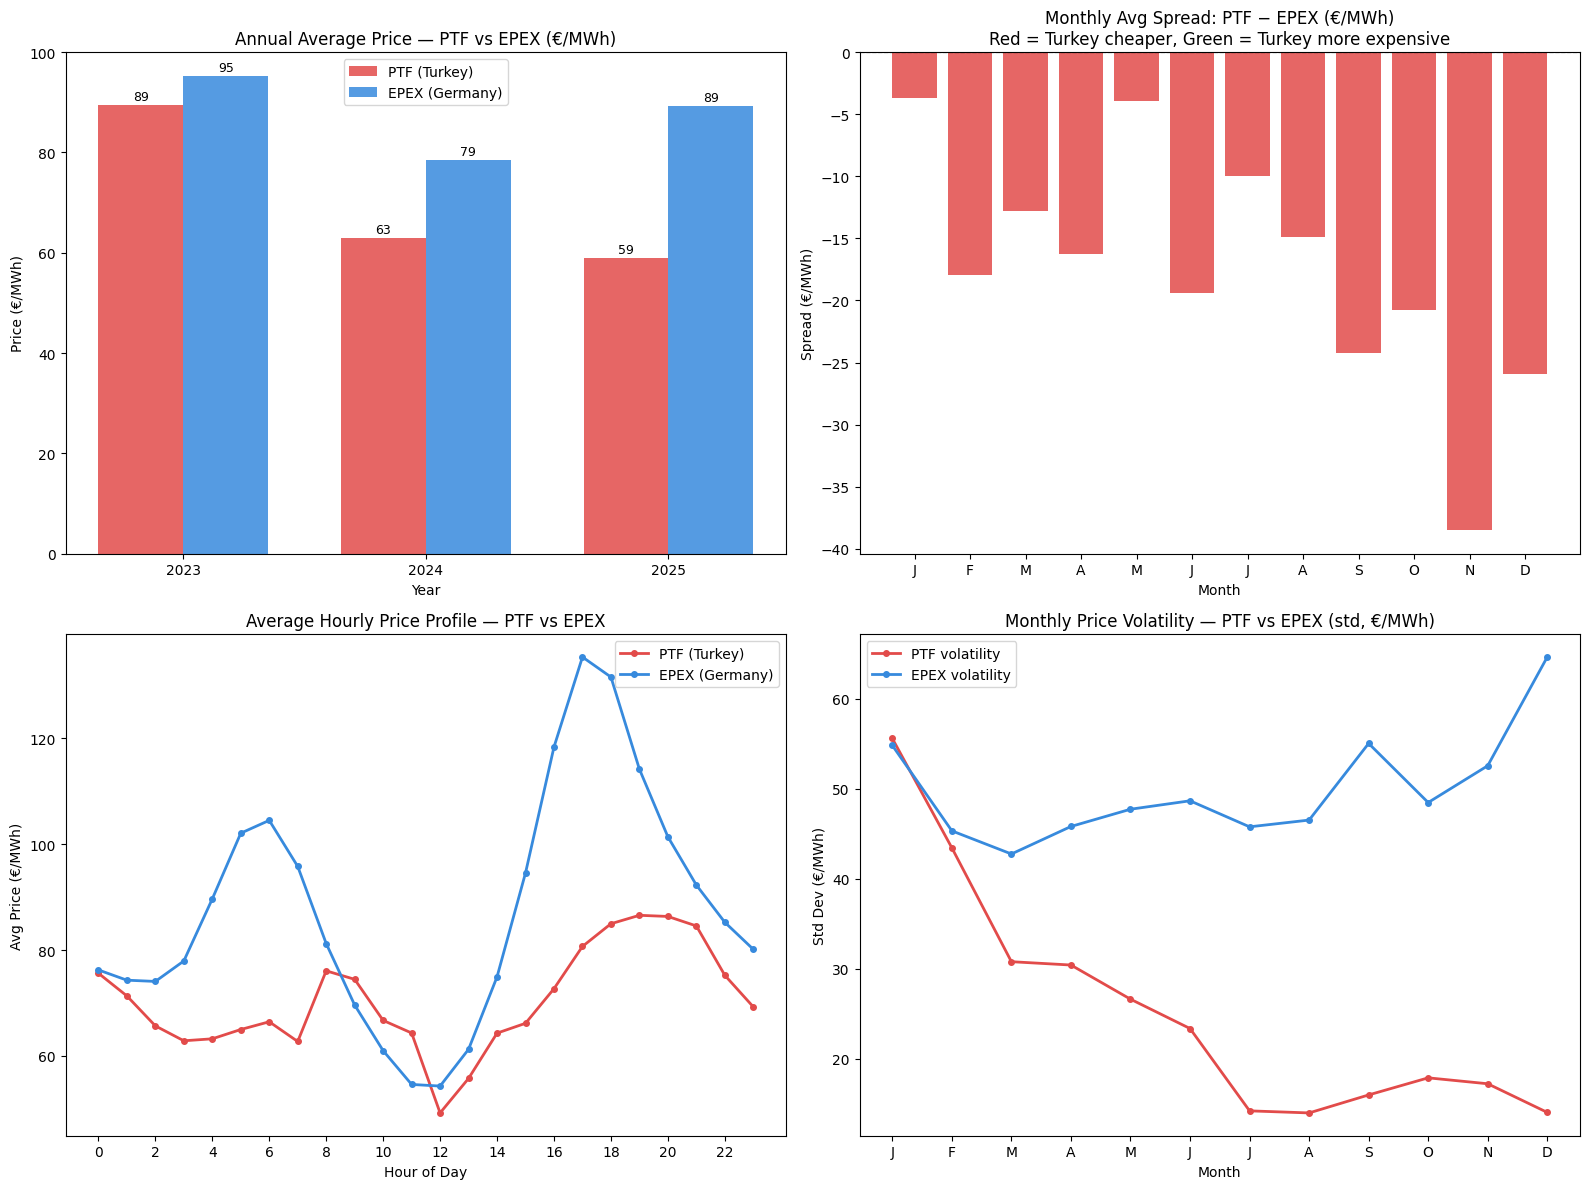

Chart saved.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Top-left: Annual average price comparison ────────────────
years       = sorted(df['year'].unique())
ptf_annual  = df.groupby('year')['ptf_eur'].mean()
epex_annual = df.groupby('year')['epex_eur'].mean()
x     = np.arange(len(years))
width = 0.35
axes[0,0].bar(x - width/2, ptf_annual.values,  width,
              label='PTF (Turkey)',   color='#E24B4A', alpha=0.85)
axes[0,0].bar(x + width/2, epex_annual.values, width,
              label='EPEX (Germany)', color='#378ADD', alpha=0.85)
axes[0,0].set_title('Annual Average Price — PTF vs EPEX (€/MWh)')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Price (€/MWh)')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(years)
axes[0,0].legend()
for i, (p, e) in enumerate(zip(ptf_annual, epex_annual)):
    axes[0,0].text(i - width/2, p + 1, f'{p:.0f}', ha='center', fontsize=9)
    axes[0,0].text(i + width/2, e + 1, f'{e:.0f}', ha='center', fontsize=9)

# ── Top-right: Monthly spread ────────────────────────────────
monthly_spread = df.groupby('month')['spread_eur'].mean()
colors = ['#E24B4A' if s < 0 else '#1D9E75' for s in monthly_spread]
axes[0,1].bar(monthly_spread.index, monthly_spread.values,
              color=colors, alpha=0.85)
axes[0,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,1].set_title('Monthly Avg Spread: PTF − EPEX (€/MWh)\nRed = Turkey cheaper, Green = Turkey more expensive')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Spread (€/MWh)')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

# ── Bottom-left: Hourly price profile ────────────────────────
hourly_ptf  = df.groupby('hour')['ptf_eur'].mean()
hourly_epex = df.groupby('hour')['epex_eur'].mean()
axes[1,0].plot(hourly_ptf.index,  hourly_ptf.values,
               color='#E24B4A', linewidth=2, marker='o', ms=4,
               label='PTF (Turkey)')
axes[1,0].plot(hourly_epex.index, hourly_epex.values,
               color='#378ADD', linewidth=2, marker='o', ms=4,
               label='EPEX (Germany)')
axes[1,0].set_title('Average Hourly Price Profile — PTF vs EPEX')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Avg Price (€/MWh)')
axes[1,0].set_xticks(range(0, 24, 2))
axes[1,0].legend()

# ── Bottom-right: Monthly volatility ─────────────────────────
vol_ptf  = df.groupby('month')['ptf_eur'].std()
vol_epex = df.groupby('month')['epex_eur'].std()
axes[1,1].plot(vol_ptf.index,  vol_ptf.values,
               color='#E24B4A', linewidth=2, marker='o', ms=4,
               label='PTF volatility')
axes[1,1].plot(vol_epex.index, vol_epex.values,
               color='#378ADD', linewidth=2, marker='o', ms=4,
               label='EPEX volatility')
axes[1,1].set_title('Monthly Price Volatility — PTF vs EPEX (std, €/MWh)')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Std Dev (€/MWh)')
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,1].legend()

plt.tight_layout()
plt.savefig('ptf_epex_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## 6 — Summary Report

In [10]:
# ── Final summary ─────────────────────────────────────────────
print('=' * 55)
print('  PTF vs EPEX COMPARISON — SUMMARY REPORT')
print('=' * 55)
print(f'  Period              : 2023–2025')
print(f'  Records             : {len(df):,} hourly observations')
print()
print(f'  Avg PTF  (Turkey)   : {df["ptf_eur"].mean():.1f} €/MWh')
print(f'  Avg EPEX (Germany)  : {df["epex_eur"].mean():.1f} €/MWh')
print(f'  Avg spread          : {df["spread_eur"].mean():.1f} €/MWh')
print(f'  Turkey cheaper      : {(df["ptf_eur"] < df["epex_eur"]).mean()*100:.1f}% of hours')
print(f'  Correlation         : {df["ptf_eur"].corr(df["epex_eur"]):.3f}')
print()
print(f'  PTF volatility      : {df["ptf_eur"].std():.1f} €/MWh')
print(f'  EPEX volatility     : {df["epex_eur"].std():.1f} €/MWh')
print(f'  Vol ratio (DE/TR)   : {df["epex_eur"].std()/df["ptf_eur"].std():.2f}x')
print()
print(f'  Negative price TR   : {(df["ptf_eur"] < 0).mean()*100:.1f}%')
print(f'  Negative price DE   : {(df["epex_eur"] < 0).mean()*100:.1f}%')
print()
print('  Annual breakdown:')
annual = df.groupby('year').agg(
    ptf_avg  = ('ptf_eur',   'mean'),
    epex_avg = ('epex_eur',  'mean'),
    spread   = ('spread_eur','mean')
).round(1)
print(annual.to_string())
print('=' * 55)

  PTF vs EPEX COMPARISON — SUMMARY REPORT
  Period              : 2023–2025
  Records             : 26,280 hourly observations

  Avg PTF  (Turkey)   : 70.4 €/MWh
  Avg EPEX (Germany)  : 87.7 €/MWh
  Avg spread          : -17.3 €/MWh
  Turkey cheaper      : 69.4% of hours
  Correlation         : 0.330

  PTF volatility      : 30.3 €/MWh
  EPEX volatility     : 51.2 €/MWh
  Vol ratio (DE/TR)   : 1.69x

  Negative price TR   : 0.0%
  Negative price DE   : 5.1%

  Annual breakdown:
      ptf_avg  epex_avg  spread
year                           
2023     89.4      95.2    -5.8
2024     62.9      78.5   -15.6
2025     58.9      89.3   -30.4
